# Libraries

In [3]:
import numpy as np

# import matplotlib.ticker as ticker
# import matplotlib.pylab as plt

# import aplpy
# import pylab as pl

import astropy.io.fits as fits
from astropy.wcs import WCS
from astropy import units as u

from spectral_cube import SpectralCube

from astropy.coordinates import SkyCoord
from astropy.wcs.utils import skycoord_to_pixel
from astropy.wcs.utils import pixel_to_skycoord

from matplotlib.patches import Ellipse

# from astropy.stats import mad_std

import matplotlib.pyplot as plt
from skimage.morphology import remove_small_objects
from astropy.wcs.utils import proj_plane_pixel_scales

import matplotlib as mpl

from radio_beam import Beam
from astropy.wcs.utils import proj_plane_pixel_area


mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # or "Computer Modern"
    "font.size": 14,

    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,

    "mathtext.fontset": "cm",  # Computer Modern for LaTeX math
})


# Functions

In [4]:
def plot_contours(data_array, color, sigma, sigma_min, sigma_max, sigma_step, ax, extent=None):
    sigma_levels = np.arange(sigma_min, sigma_max + sigma_step, sigma_step)
    levels = sigma * sigma_levels

    return ax.contour(
        data_array,
        levels=levels,
        colors=color,
        linewidths=0.5,
        origin='lower',
        extent=extent,
    )

def beam(beam_minor, beam_major, beam_pa, beam_xposition, beam_yposition):
    # Set beam location
    beam_x = ra_offsets.min() + beam_xposition  
    beam_y = dec_offsets.min() + beam_yposition

    # Create the beam ellipse
    return Ellipse(
        (beam_x, beam_y),
        width=beam_major,
        height=beam_minor,
        angle=beam_pa,
        edgecolor='black',
        facecolor='black',
        alpha=0.7,
        zorder=10
    )


# Coordinates for HOPS-164 

In [10]:
# HOPS-164 Coordinates from Tobin et al
marker_coord = SkyCoord("5h37m00.425s", "-6d37m10.89s", frame='icrs')

# Create a sky offset frame centered on the marker
offset_frame = marker_coord.skyoffset_frame()


# Read Beam Sizes 

In [11]:
# Load the FITS file
# fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/N2Dp/HOPS164_N2Dp_large_sm_reb.fits'
# fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/N2Dp/HOPS164_N2Dp_Tp12m7m_large_Combine_pbcor.fits'
# fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/H2CO/HOPS164_H2CO_Tp12m7m_Combine_pbcor_masked.fits'
# fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/C18O/HOPS164_C18O_Tp12m7m_Combine_pbcor_masked.fits'
# fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/13CO/HOPS164_13CO_Tp12m7m_Combine_pbcor_masked.fits'
# fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/CO/HOPS164_CO_Tp12m7m_Combine_pbcor_masked.fits'
# fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/Continuum/HOPS-164_cont_robust0.5.pbcor.fits'
# fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/Continuum/HOPS-164_Continuum_natural_thres0.4mJy.pbcor.fits'
fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/CARMA/CARMA_NRO_Orion_c18o_HOPS-164.fits'

hdu = fits.open(fits_file)[0]  # Open the primary HDU
wcs = WCS(hdu.header)          # Extract WCS projection

header = hdu.header

# Extract beam parameters and convert degrees to arcseconds
bmaj = header.get('BMAJ', 0) * 3600  # major axis in arcsec
bmin = header.get('BMIN', 0) * 3600  # minor axis in arcsec
bpa  = header.get('BPA', 0)          # position angle in degrees

print(f"Beam major axis: {bmaj:.2f}\"")
print(f"Beam minor axis: {bmin:.2f}\"")
print(f"Beam position angle: {bpa:.2f}°")

Beam major axis: 10.50"
Beam minor axis: 7.74"
Beam position angle: -0.40°


# Continuum

In [12]:
hdul = fits.open('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/Continuum/HOPS-164_Continuum_natural_thres0.4mJy.pbcor.fits')

data = hdul[0].data.squeeze()
header = hdul[0].header
wcs = WCS(header)

# Beam info
beam_header = Beam.from_fits_header(header)

# Frequency
freq = 232.6 * u.GHz

# Convert Jy/beam -> K
jybeam_to_K = u.Jy.to(
    u.K,
    equivalencies=u.brightness_temperature(
        frequency=freq,
        beam_area=beam_header.sr
    )
)

data_K = data * jybeam_to_K

In [13]:
ny, nx = data_K.shape
print(f"Data shape: {data_K.shape}")
y_pix, x_pix = np.mgrid[:ny, :nx]
sky = pixel_to_skycoord(x_pix, y_pix, wcs.celestial)

# Convert sky coordinates to offset frame
offset_coords = sky.transform_to(offset_frame)
ra_offsets = -offset_coords.lon.arcsec
dec_offsets = offset_coords.lat.arcsec

extent_continuum=[
    ra_offsets.min(), ra_offsets.max(),
    dec_offsets.min(), dec_offsets.max()
]

Data shape: (448, 448)


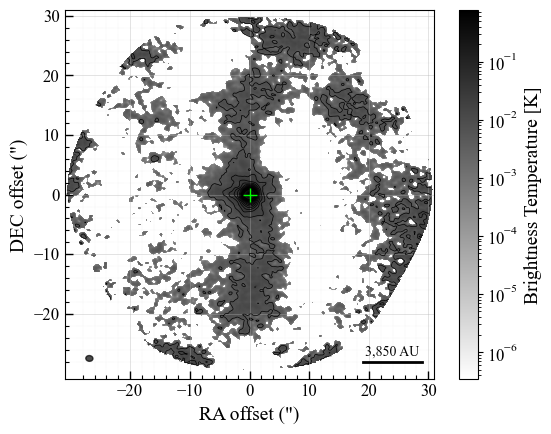

In [17]:
# Plot using offsets
fig, ax = plt.subplots()
# im = ax.imshow(data_K, origin='lower', cmap='binary', vmin=0, vmax=0.06, extent=[
#     ra_offsets.min(), ra_offsets.max(),
#     dec_offsets.min(), dec_offsets.max()
# ])

from matplotlib.colors import LogNorm

im = ax.imshow(data_K, origin='lower', cmap='binary', norm=LogNorm(), extent=[
    ra_offsets.min(), ra_offsets.max(),
    dec_offsets.min(), dec_offsets.max()
])

sigma_continuum = 0.002

# Plot contours
plot_contours(data_K, 'black', sigma_continuum, sigma_min=3, sigma_max=100, sigma_step=5, ax=ax, extent=extent_continuum)

# Plot the protostar marker
ax.plot(0, 0, marker='+', color='lime', markersize=10, label='Marker')

# Set labels
ax.set_xlabel('RA offset (")')
ax.set_ylabel('DEC offset (")')
# ax.set_title('1.3 mm Dust Continuum')

# Move ticks inside
ax.tick_params(axis='both', direction='in', which='both')

# Add colorbar
plt.colorbar(im, ax=ax, label='Brightness Temperature [K]')

# Add beam
beam_continuum = beam(1.20, 0.97, 85.18, 12, 10)
ax.add_patch(beam_continuum)

ax.set_xlim(-31, 31) 
ax.set_ylim(-31, 31)

# Set major ticks 
ax.set_xticks(np.arange(-20, 31, 10))
ax.set_yticks(np.arange(-20, 31, 10))

# Set minor ticks 
ax.set_xticks(np.arange(-28, 30, 2), minor=True)
ax.set_yticks(np.arange(-28, 30, 2), minor=True)

# Change tick appearance
ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

# Set starting point for the scale bar (in arcseconds from frame)
x_start = ax.get_xlim()[0] + 50      
y_start = ax.get_ylim()[0] + 3       

# Length of the bar in arcseconds
scale_bar_length = 10  

# Plot the scale bar
ax.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

# Label it
ax.text(x_start + scale_bar_length / 2, y_start + 0.5, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.5)
ax.grid(which='minor', linestyle=':', linewidth=0.3, alpha=0.3)

# Save image
# plt.savefig("HOPS164_1.3mm_continnum.png", format="png", dpi=300, bbox_inches="tight")
# plt.savefig("HOPS164_1.3mm_continnum.pdf", format="pdf", dpi=300, bbox_inches="tight")

# Close imshow
plt.show()

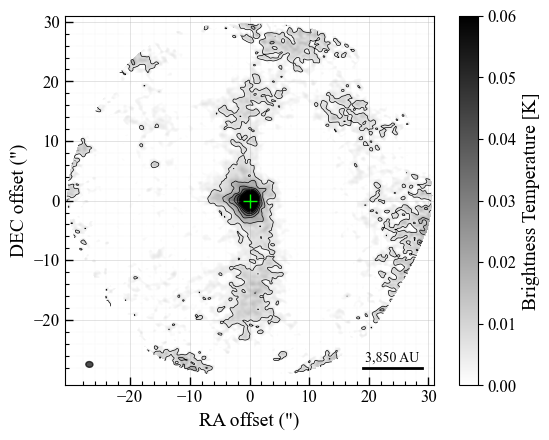

In [18]:
# Plot using offsets
fig, ax = plt.subplots()
im = ax.imshow(data_K, origin='lower', cmap='binary', vmin=0, vmax=0.06, extent=[
    ra_offsets.min(), ra_offsets.max(),
    dec_offsets.min(), dec_offsets.max()
])

sigma_continuum = 0.002

# Plot contours
plot_contours(data_K, 'black', sigma_continuum, sigma_min=3, sigma_max=100, sigma_step=5, ax=ax, extent=extent_continuum)

# Plot the protostar marker
ax.plot(0, 0, marker='+', color='lime', markersize=10, label='Marker')

# Set labels
ax.set_xlabel('RA offset (")')
ax.set_ylabel('DEC offset (")')
# ax.set_title('1.3 mm Dust Continuum')

# Move ticks inside
ax.tick_params(axis='both', direction='in', which='both')

# Add colorbar
plt.colorbar(im, ax=ax, label='Brightness Temperature [K]')

# Add beam
beam_continuum = beam(1.20, 0.97, 85.18, 12, 10)
ax.add_patch(beam_continuum)

ax.set_xlim(-31, 31) 
ax.set_ylim(-31, 31)

# Set major ticks 
ax.set_xticks(np.arange(-20, 31, 10))
ax.set_yticks(np.arange(-20, 31, 10))

# Set minor ticks 
ax.set_xticks(np.arange(-28, 30, 2), minor=True)
ax.set_yticks(np.arange(-28, 30, 2), minor=True)

# Change tick appearance
ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

# Set starting point for the scale bar (in arcseconds from frame)
x_start = ax.get_xlim()[0] + 50      
y_start = ax.get_ylim()[0] + 3       

# Length of the bar in arcseconds
scale_bar_length = 10  

# Plot the scale bar
ax.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

# Label it
ax.text(x_start + scale_bar_length / 2, y_start + 0.5, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.5)
ax.grid(which='minor', linestyle=':', linewidth=0.3, alpha=0.3)

# Save image
# plt.savefig("HOPS164_1.3mm_continnum.png", format="png", dpi=300, bbox_inches="tight")
# plt.savefig("HOPS164_1.3mm_continnum.pdf", format="pdf", dpi=300, bbox_inches="tight")

# Close imshow
plt.show()

# 12CO Moment 0

In [12]:
cube_12CO = SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/CO/HOPS164_CO_Tp12m7m_Combine_pbcor_masked.fits')
cube_12CO.allow_huge_operations = True 
cube_12CO = cube_12CO.to(u.K).with_spectral_unit(u.km/u.s)

In [ ]:
# # Coordinates that APPEAR at the center of the protostar in ALMA data
# # marker_coord = SkyCoord("5h37m00.425s", "-6d37m10.89s", frame='icrs')

# marker_coord = pixel_to_skycoord(229, 221, cube_12CO.wcs.celestial)

# # Create a sky offset frame centered on the marker
# offset_frame = marker_coord.skyoffset_frame()

# # Access robust data
# data_robust = cube_12CO.hdu.data

# # Convert pixel grid to world coordinates
# nx = cube_12CO.shape[1]
# ny = cube_12CO.shape[2]
# y_pix, x_pix = np.mgrid[:ny, :nx]
# sky = pixel_to_skycoord(x_pix, y_pix, cube_12CO.wcs.celestial)

# # Convert sky coordinates to offset frame
# offset_coords = sky.transform_to(offset_frame)
# ra_offsets = -offset_coords.lon.arcsec
# dec_offsets = offset_coords.lat.arcsec


In [14]:
slab_12CO = cube_12CO.spectral_slab(0*u.km/u.s, 11.6*u.km/u.s)
data_moment0_12CO = slab_12CO.moment(order=0).hdu.data 

slab_moment1_12CO = cube_12CO.spectral_slab(0*u.km/u.s, 11.6*u.km/u.s)
data_moment1_12CO = slab_moment1_12CO.moment(order=1).hdu.data  

# Outflow
slab_12CO_blue = cube_12CO.spectral_slab(0*u.km/u.s, 4.2*u.km/u.s)
data_moment0_12CO_blue = slab_12CO_blue.moment(order=0).hdu.data  

slab_12CO_red = cube_12CO.spectral_slab(7.2*u.km/u.s, 11.6*u.km/u.s)
data_moment0_12CO_red = slab_12CO_red.moment(order=0).hdu.data  

/Users/ivarismartinez/anaconda3/envs/umbrella/lib/python3.11/site-packages/spectral_cube/_moments.py:182: RuntimeWarning: invalid value encountered in divide
  return (np.nansum(data * pix_cen, axis=axis) /


In [15]:
sigma_12CO = 0.13 # found using moment 5

# Finding rms
dv = np.abs(np.diff(slab_12CO.spectral_axis)[0])
N = slab_12CO.shape[0]
sigma_12CO = sigma_12CO * np.sqrt(N) * dv
print(sigma_12CO)

# Finding rms
dv = np.abs(np.diff(slab_12CO_blue.spectral_axis)[0])
N = slab_12CO_blue.shape[0]
sigma_12CO_blue = sigma_12CO * np.sqrt(N) * dv
print(sigma_12CO_blue)

# Finding rms
dv = np.abs(np.diff(slab_12CO_red.spectral_axis)[0])
N = slab_12CO_red.shape[0]
sigma_12CO_red = sigma_12CO * np.sqrt(N) * dv
print(sigma_12CO_red)

0.12510960794275786 km / s
0.0729753499849434 km2 / s2
0.07431445892708813 km2 / s2


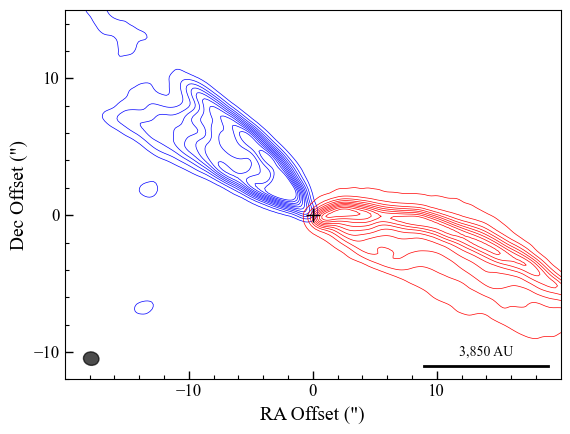

In [16]:
# Plot using offsets
fig, ax = plt.subplots()
# im = ax.imshow(data_moment0_12CO, origin='lower', cmap='binary', vmin=0, extent=[
#     ra_offsets.min(), ra_offsets.max(),
#     dec_offsets.min(), dec_offsets.max()])

# Plot contours
plot_contours(data_moment0_12CO_blue, 'blue', sigma_12CO_blue, sigma_min=70, sigma_max=550, sigma_step=50)
plot_contours(data_moment0_12CO_red, 'red', sigma_12CO_red, sigma_min=170, sigma_max=800, sigma_step=70)
# plot_contours(data_moment0_12CO, 'black', sigma_12CO, sigma_min=50, sigma_max=800, sigma_step=10)

# Plot the protostar marker
ax.plot(0, 0, marker='+', color='black', markersize=10, label='Marker')

# Set labels
ax.set_xlabel('RA Offset (")')
ax.set_ylabel('Dec Offset (")')
# ax.set_title(r'$^{12}$CO')

# Add velocity label in the top left of the subplot
# ax.text(0.05, 0.95, f"{0:.0f} - {11.0:.0f} km/s", transform=ax.transAxes, fontsize=12, verticalalignment='top', color = 'black', bbox=dict(facecolor='white', alpha=0.7))
# ax.text(0.65, 0.95, f"{0:.0f} - {4.2:.1f} km/s", transform=ax.transAxes, fontsize=12, verticalalignment='top', color = 'blue', bbox=dict(facecolor='white', alpha=0.7))
# ax.text(0.65, 0.85, f"{7.2:.1f} - {11.6:.1f} km/s", transform=ax.transAxes, fontsize=12, verticalalignment='top', color = 'red', bbox=dict(facecolor='white', alpha=0.7))

# Move ticks inside
ax.tick_params(axis='both', direction='in', which='both')

# Add colorbar
# plt.colorbar(im, ax=ax, label='K.km/s')

# Add beam
beam_12CO = beam(1.25, 0.98, 84.20, 21, 27)
ax.add_patch(beam_12CO)

# Set offset limits
ax.set_xlim(-20, 20)
ax.set_ylim(-10, 15)

# Set major ticks      
ax.set_xticks(np.arange(-10, 20, 10))
ax.set_yticks(np.arange(-10, 15, 10))

# Set minor ticks  
ax.set_xticks(np.arange(-18, 20, 2), minor=True)
ax.set_yticks(np.arange(-12, 16, 2), minor=True)

# Change tick appearance
ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

# Set starting point for the scale bar (in arcseconds)
x_start = ax.get_xlim()[0] + 29    
y_start = ax.get_ylim()[0] + 1    

# Length of the bar in arcseconds
scale_bar_length = 10  

# Plot the scale bar
ax.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

# Label it
ax.text(x_start + scale_bar_length / 2, y_start + 0.5, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

# Save image
# plt.savefig("HOPS164_12CO_moment0_map.png", format="png", dpi=300, bbox_inches="tight")
# plt.savefig("HOPS164_12CO_moment0_map.pdf", format="pdf", dpi=300, bbox_inches="tight")

# Close imshow
plt.show()

# 12CO Moment 1

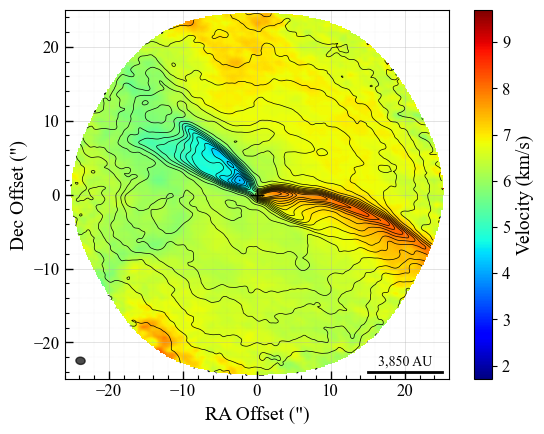

In [17]:
# Plot using offsets
fig, ax = plt.subplots()
# fig.patch.set_facecolor('black')   # figure background
# ax.set_facecolor('black')  

im = ax.imshow(data_moment1_12CO, origin='lower', cmap='jet', vmin=5.7 - 4, vmax=5.7 + 4, extent=[
    ra_offsets.min(), ra_offsets.max(),
    dec_offsets.min(), dec_offsets.max()])

# Plot contours
plot_contours(data_moment0_12CO, 'black', sigma_12CO, sigma_min=50, sigma_max=800, sigma_step=40)

# Plot the protostar marker
ax.plot(0, 0, marker='+', color='black', markersize=10, label='Marker')

# Set labels
ax.set_xlabel('RA Offset (")')
ax.set_ylabel('Dec Offset (")')
# ax.set_title(r'$^{12}$CO')

# Move ticks inside
ax.tick_params(axis='both', direction='in', which='both')

# Add colorbar
plt.colorbar(im, ax=ax, label='Velocity (km/s)')

# Add beam
beam_12CO = beam(1.25, 0.98, 84.20, 15, 15)
ax.add_patch(beam_12CO)

# Set offset limits
ax.set_xlim(-26, 26)
ax.set_ylim(-25, 25)

# Set major ticks      
ax.set_xticks(np.arange(-20, 25, 10))
ax.set_yticks(np.arange(-20, 25, 10))

# Set minor ticks  
ax.set_xticks(np.arange(-26, 26, 2), minor=True)
ax.set_yticks(np.arange(-26, 26, 2), minor=True)

# Change tick appearance
ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

# Set starting point for the scale bar (in arcseconds)
x_start = ax.get_xlim()[0] + 41    
y_start = ax.get_ylim()[0] + 2
    

# Length of the bar in arcseconds
scale_bar_length = 10  

# Plot the scale bar
ax.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

# Label it
ax.text(x_start + scale_bar_length / 2, y_start + 0.5, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

# Set offset limits
ax.set_xlim(-26, 26)
ax.set_ylim(-25, 25)

ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.5)
ax.grid(which='minor', linestyle=':', linewidth=0.3, alpha=0.3)


# Save image
plt.savefig("HOPS164_12CO_moment1_map.png", format="png", dpi=300, bbox_inches="tight")
plt.savefig("HOPS164_12CO_moment1_map.pdf", format="pdf", dpi=300, bbox_inches="tight")

# Close imshow
plt.show()

# 13CO

In [18]:
cube_13CO = SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/13CO/HOPS164_13CO_Tp12m7m_Combine_pbcor_masked.fits')
cube_13CO = cube_13CO.to(u.K).with_spectral_unit(u.km/u.s)

In [19]:
# # Coordinates that APPEAR at the center of the protostar in ALMA data
# marker_coord = SkyCoord("5h37m00.540s", "-6d37m10.75s", frame='icrs')

# # Create a sky offset frame centered on the marker
# offset_frame = marker_coord.skyoffset_frame()

# # Transform it to the same offset frame as your image
# marker_offset = marker_coord.transform_to(offset_frame)

# # Access robust data
# data_robust = cube_13CO.hdu.data

# # Convert pixel grid to world coordinates
# nx = cube_13CO.shape[1]
# ny = cube_13CO.shape[2]
# y_pix, x_pix = np.mgrid[:ny, :nx]
# sky = pixel_to_skycoord(x_pix, y_pix, cube_13CO.wcs.celestial)

# # Convert sky coordinates to offset frame
# offset_coords = sky.transform_to(offset_frame)
# ra_offsets = -offset_coords.lon.arcsec
# dec_offsets = offset_coords.lat.arcsec

# x_marker, y_marker = skycoord_to_pixel(marker_coord, cube_13CO.wcs.celestial)

In [20]:
vmin_13CO = 1.4
vmax_13CO = 9.8

slab_13CO = cube_13CO.spectral_slab(vmin_13CO*u.km/u.s, vmax_13CO*u.km/u.s)
data_moment0_13CO = slab_13CO.moment(order=0).hdu.data

moment1_13CO = slab_13CO.moment(order=1)
data_moment1_13CO = moment1_13CO.hdu.data

/Users/ivarismartinez/anaconda3/envs/umbrella/lib/python3.11/site-packages/spectral_cube/_moments.py:182: RuntimeWarning: invalid value encountered in divide
  return (np.nansum(data * pix_cen, axis=axis) /


In [21]:
sigma_13CO = 0.17

# Finding RMS
dv = np.abs(np.diff(slab_13CO.spectral_axis)[0])
N = slab_13CO.shape[0]
sigma_13CO = sigma_13CO * np.sqrt(N) * dv
print(sigma_13CO)

0.14255129767690938 km / s


# 13CO Moment 0

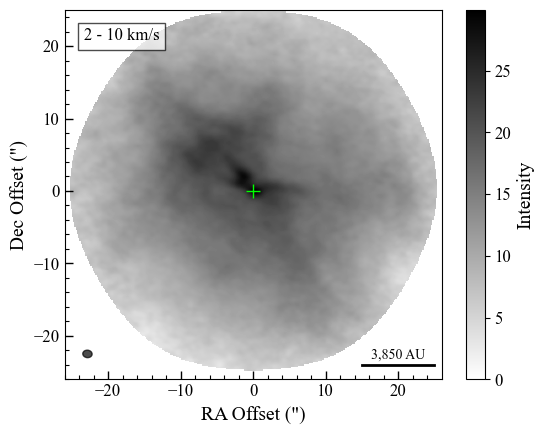

In [22]:
# Plot using offsets
fig, ax = plt.subplots()
im = ax.imshow(data_moment0_13CO, origin='lower', cmap='binary', vmin=0, extent=[
    ra_offsets.min(), ra_offsets.max(),
    dec_offsets.min(), dec_offsets.max()
])

# Plot contours
# plot_contours(data_13CO, 'black', sigma_13CO, sigma_min=50, sigma_max=250, sigma_step=5)

# Plot the protostar marker
ax.plot(0, 0, marker='+', color='lime', markersize=10, label='Marker')

# Set labels
ax.set_xlabel('RA Offset (")')
ax.set_ylabel('Dec Offset (")')
# ax.set_title(r'$^{13}$CO')

# Add velocity label in the top left of the subplot
ax.text(0.05, 0.95, f"{2:.0f} - {10:.0f} km/s", transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))

# Move ticks inside
ax.tick_params(axis='both', direction='in', which='both')

# Add colorbar
plt.colorbar(im, ax=ax, label='Intensity')

# Add beam
beam_13CO = beam(1.29, 1.03, 84.42, 16, 15)
ax.add_patch(beam_13CO)

# Set offset limits
ax.set_xlim(-26, 26)
ax.set_ylim(-25, 25)

# Set major ticks      
ax.set_xticks(np.arange(-20, 25, 10))
ax.set_yticks(np.arange(-20, 25, 10))

# Set minor ticks  
ax.set_xticks(np.arange(-26, 26, 2), minor=True)
ax.set_yticks(np.arange(-26, 26, 2), minor=True)

# Change tick appearance
ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

# Set starting point for the scale bar (in arcseconds)
x_start = ax.get_xlim()[0] + 41      
y_start = ax.get_ylim()[0] + 2       

# Length of the bar in arcseconds
scale_bar_length = 10      

# Plot the scale bar
ax.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

# Label it
ax.text(x_start + scale_bar_length / 2, y_start + 0.5, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

# Save image
# plt.savefig("HOPS164_13CO_contour_map.png", format="png", dpi=300, bbox_inches="tight")

# Close imshow
plt.show()

# 13CO Moment 1

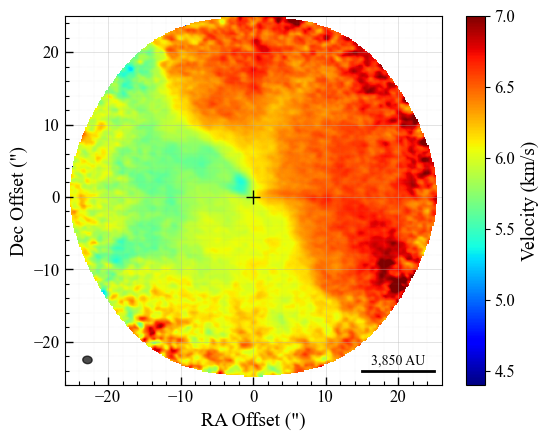

In [23]:
# Plot using offsets
fig, ax = plt.subplots()
# im = ax.imshow(data_moment1_13CO, origin='lower', cmap='jet', vmin=vmin_13CO, vmax=vmax_13CO, extent=[
#     ra_offsets.min(), ra_offsets.max(),
#     dec_offsets.min(), dec_offsets.max()])

im = ax.imshow(data_moment1_13CO, origin='lower', cmap='jet', vmin=4.4, vmax=7.0, extent=[
    ra_offsets.min(), ra_offsets.max(),
    dec_offsets.min(), dec_offsets.max()])

# Plot contours
# plot_contours(data_13CO, 'black', sigma_13CO, sigma_min=50, sigma_max=250, sigma_step=10)

# Plot the protostar marker
ax.plot(0, 0, marker='+', color='black', markersize=10, label='Marker')

# Set labels
ax.set_xlabel('RA Offset (")')
ax.set_ylabel('Dec Offset (")')
# ax.set_title(r'$^{13}$CO')

# Move ticks inside
ax.tick_params(axis='both', direction='in', which='both')

# Add colorbar
plt.colorbar(im, ax=ax, label='Velocity (km/s)')

# Add beam
beam_13CO = beam(1.29, 1.03, 84.42, 16, 15)
ax.add_patch(beam_13CO)

# Set offset limits
ax.set_xlim(-26, 26)
ax.set_ylim(-25, 25)

# Set major ticks      
ax.set_xticks(np.arange(-20, 25, 10))
ax.set_yticks(np.arange(-20, 25, 10))

# Set minor ticks  
ax.set_xticks(np.arange(-26, 26, 2), minor=True)
ax.set_yticks(np.arange(-26, 26, 2), minor=True)

# Change tick appearance
ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

# Set starting point for the scale bar (in arcseconds)
x_start = ax.get_xlim()[0] + 41      
y_start = ax.get_ylim()[0] + 2       

# Length of the bar in arcseconds
scale_bar_length = 10      

# Plot the scale bar
ax.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

# Label it
ax.text(x_start + scale_bar_length / 2, y_start + 0.5, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.5)
ax.grid(which='minor', linestyle=':', linewidth=0.3, alpha=0.3)

# Save image
plt.savefig("HOPS164_13CO_moment1_map.png", format="png", dpi=300, bbox_inches="tight")
plt.savefig("HOPS164_13CO_moment1_map.pdf", format="pdf", dpi=300, bbox_inches="tight")

# Close imshow
plt.show()

# C18O

In [24]:
cube_C18O=SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/C18O/HOPS164_C18O_Tp12m7m_Combine_pbcor_masked.fits')
cube_C18O = cube_C18O.to(u.K).with_spectral_unit(u.km/u.s)

In [ ]:
# # Access robust data
# data_robust = cube_C18O.hdu.data

# # Convert pixel grid to world coordinates
# nx = cube_C18O.shape[1]
# ny = cube_C18O.shape[2]
# y_pix, x_pix = np.mgrid[:ny, :nx]
# sky = pixel_to_skycoord(x_pix, y_pix, cube_C18O.wcs.celestial)

# # Convert sky coordinates to offset frame
# offset_coords = sky.transform_to(offset_frame)
# ra_offsets = -offset_coords.lon.arcsec
# dec_offsets = offset_coords.lat.arcsec

In [26]:
# Encompass all emission:
vmin_C18O = 3.7
vmax_C18O = 8.2

sigma_C18O = 0.13 

# NOT NECCESSARY
# mask = cube_C18O > 3 * sigma_C18O * u.K
# cube_masked_C18O = cube_C18O.with_mask(mask)

In [27]:
slab_C18O = cube_C18O.spectral_slab(vmin_C18O*u.km/u.s, vmax_C18O*u.km/u.s)
data_moment0_C18O = slab_C18O.moment(order=0).hdu.data

slab_C18O = cube_C18O.spectral_slab(vmin_C18O*u.km/u.s, vmax_C18O*u.km/u.s)
data_moment1_C18O = slab_C18O.moment(order=1).hdu.data

/Users/ivarismartinez/anaconda3/envs/umbrella/lib/python3.11/site-packages/spectral_cube/_moments.py:182: RuntimeWarning: invalid value encountered in divide
  return (np.nansum(data * pix_cen, axis=axis) /


In [28]:
sigma_C18O = 0.13

# Finding RMS
dv = np.abs(np.diff(slab_C18O.spectral_axis)[0])
N = slab_C18O.shape[0]
sigma_C18O = sigma_C18O * np.sqrt(N) * dv
print(sigma_C18O)

0.08035296953801055 km / s


# C18O Moment 0

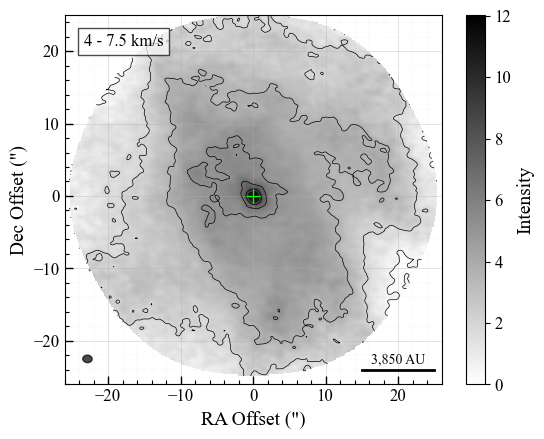

In [29]:
# Plot using offsets
fig, ax = plt.subplots()
im = ax.imshow(data_moment0_C18O, origin='lower', cmap='binary', vmin=0, extent=[
    ra_offsets.min(), ra_offsets.max(),
    dec_offsets.min(), dec_offsets.max()
])

# Plot contours
plot_contours(data_moment0_C18O, 'black', sigma_C18O, sigma_min=5, sigma_max=250, sigma_step=20)

# Plot the protostar marker
ax.plot(0, 0, marker='+', color='lime', markersize=10, label='Marker')

# Set labels
ax.set_xlabel('RA Offset (")')
ax.set_ylabel('Dec Offset (")')
# ax.set_title(r'C$^{18}$O')

# Add velocity label in the top left of the subplot
ax.text(0.05, 0.95, f"{4.0:.0f} - {7.5:.1f} km/s", transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))

# Move ticks inside
ax.tick_params(axis='both', direction='in', which='both')

# Add colorbar
plt.colorbar(im, ax=ax, label='Intensity')

# Add beam
beam_C18O = beam(1.30, 1.03, 85.77, 16, 15)
ax.add_patch(beam_C18O)

# Set offset limits
ax.set_xlim(-26, 26)
ax.set_ylim(-25, 25)

# Set major ticks      
ax.set_xticks(np.arange(-20, 25, 10))
ax.set_yticks(np.arange(-20, 25, 10))

# Set minor ticks  
ax.set_xticks(np.arange(-26, 26, 2), minor=True)
ax.set_yticks(np.arange(-26, 26, 2), minor=True)

# Change tick appearance
ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

# Set starting point for the scale bar (in arcseconds)
x_start = ax.get_xlim()[0] + 41      
y_start = ax.get_ylim()[0] + 2       

# Length of the bar in arcseconds
scale_bar_length = 10      

# Plot the scale bar
ax.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

# Label it
ax.text(x_start + scale_bar_length / 2, y_start + 0.5, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.5)
ax.grid(which='minor', linestyle=':', linewidth=0.3, alpha=0.3)

# Save image
# plt.savefig("HOPS164_C18O_contour_map.png", format="png", dpi=300, bbox_inches="tight")

# Close imshow
plt.show()

# C18O Moment 1

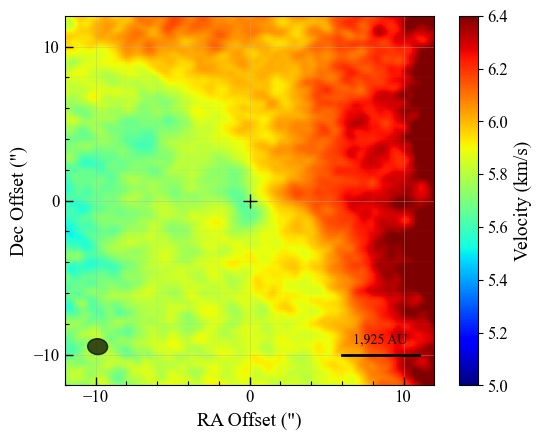

In [30]:
# Plot using offsets
fig, ax = plt.subplots()
# im = ax.imshow(data_moment1_C18O, origin='lower', cmap='jet', vmin=vmin_C18O, vmax= vmax_C18O, extent=[
#     ra_offsets.min(), ra_offsets.max(),
#     dec_offsets.min(), dec_offsets.max()])

im = ax.imshow(data_moment1_C18O, origin='lower', cmap='jet', vmin=5.0, vmax= 6.4, extent=[
    ra_offsets.min(), ra_offsets.max(),
    dec_offsets.min(), dec_offsets.max()])

# Plot contours
# plot_contours(data_moment0_C18O, 'black', sigma_C18O, sigma_min=5, sigma_max=250, sigma_step=20)

# Plot the protostar marker
ax.plot(0, 0, marker='+', color='black', markersize=10, label='Marker')

# Set labels
ax.set_xlabel('RA Offset (")')
ax.set_ylabel('Dec Offset (")')
# ax.set_title(r'C$^{18}$O')
# Move ticks inside
ax.tick_params(axis='both', direction='in', which='both')

# Add colorbar
plt.colorbar(im, ax=ax, label='Velocity (km/s)')

# Add beam
beam_C18O = beam(1.30, 1.03, 85.77, 29, 28)
ax.add_patch(beam_C18O)

# Set offset limits
ax.set_xlim(-10, 12)
ax.set_ylim(-10, 12)

# Set major ticks      
ax.set_xticks(np.arange(-10, 11, 10))
ax.set_yticks(np.arange(-10, 11, 10))

# Set minor ticks  
ax.set_xticks(np.arange(-12, 12, 2), minor=True)
ax.set_yticks(np.arange(-12, 12, 2), minor=True)

# Change tick appearance
ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

# Set starting point for the scale bar (in arcseconds)
x_start = ax.get_xlim()[0] + 18      
y_start = ax.get_ylim()[0] + 2       

# Length of the bar in arcseconds
scale_bar_length = 5      

# Plot the scale bar
ax.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

# Label it
ax.text(x_start + scale_bar_length / 2, y_start + 0.5, "1,925 AU",
        color='black', ha='center', va='bottom', fontsize=10)

ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.5)
ax.grid(which='minor', linestyle=':', linewidth=0.3, alpha=0.3)

# Save image
plt.savefig("HOPS164_C18O_moment1_map.png", format="png", dpi=300, bbox_inches="tight")
plt.savefig("HOPS164_C18O_moment1_map.pdf", format="pdf", dpi=300, bbox_inches="tight")

# Close imshow
plt.show()

# H2CO

In [31]:
cube_H2CO=SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/H2CO/HOPS164_H2CO_Tp12m7m_Combine_pbcor_masked.fits')
cube_H2CO = cube_H2CO.to(u.K).with_spectral_unit(u.km/u.s)

In [ ]:
# # Access robust data
# data_robust = cube_H2CO.hdu.data

# # Convert pixel grid to world coordinates
# nx = cube_H2CO.shape[1]
# ny = cube_H2CO.shape[2]
# y_pix, x_pix = np.mgrid[:ny, :nx]
# sky = pixel_to_skycoord(x_pix, y_pix, cube_H2CO.wcs.celestial)

# # Convert sky coordinates to offset frame
# offset_coords = sky.transform_to(offset_frame)
# ra_offsets = -offset_coords.lon.arcsec
# dec_offsets = offset_coords.lat.arcsec

In [33]:
# Emission
vmin_H2CO = 3.0
vmax_H2CO = 10.7

sigma_H2CO = 0.11

mask = cube_H2CO > 5 * sigma_H2CO * u.K
mask_array = mask.include()   # convert LazyComparisonMask → boolean array

planemask = remove_small_objects(mask_array, min_size=80)

cube_H2CO = cube_H2CO.with_mask(planemask)

In [34]:
slab_H2CO = cube_H2CO.spectral_slab(vmin_H2CO*u.km/u.s, vmax_H2CO*u.km/u.s)
data_moment0_H2CO = slab_H2CO.moment(order=0).hdu.data

slab_H2CO = cube_H2CO.spectral_slab(vmin_H2CO*u.km/u.s, vmax_H2CO*u.km/u.s)
data_moment1_H2CO = slab_H2CO.moment(order=1).hdu.data

/Users/ivarismartinez/anaconda3/envs/umbrella/lib/python3.11/site-packages/spectral_cube/_moments.py:182: RuntimeWarning: invalid value encountered in divide
  return (np.nansum(data * pix_cen, axis=axis) /


In [35]:
sigma_H2CO = 0.11

# Finding RMS
dv = np.abs(np.diff(slab_H2CO.spectral_axis)[0])
N = slab_H2CO.shape[0]
sigma_H2CO = sigma_H2CO * np.sqrt(N) * dv
print(sigma_H2CO)

0.08895419018233984 km / s


# H2CO Moment 0

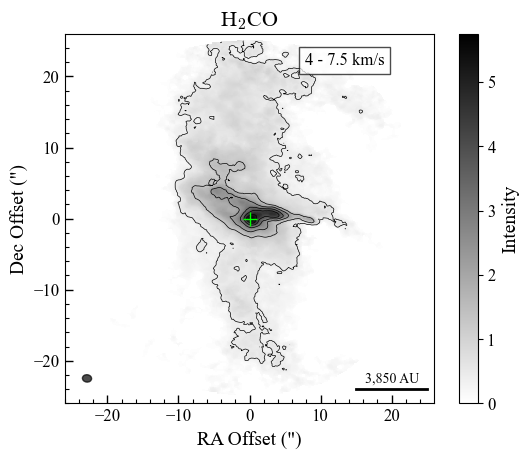

In [36]:
# Plot using offsets
fig, ax = plt.subplots()
im = ax.imshow(data_moment0_H2CO, origin='lower', cmap='binary', vmin=0, extent=[
    ra_offsets.min(), ra_offsets.max(),
    dec_offsets.min(), dec_offsets.max()
])

# Plot contours
plot_contours(data_moment0_H2CO, 'black', sigma_H2CO, sigma_min=5, sigma_max=60, sigma_step=10)

# Plot the protostar marker
ax.plot(0, 0, marker='+', color='lime', markersize=10, label='Marker')

# Set labels
ax.set_xlabel('RA Offset (")')
ax.set_ylabel('Dec Offset (")')
ax.set_title(r'H$_2$CO')

# Add velocity label in the top left of the subplot
ax.text(0.65, 0.95, f"{4.0:.0f} - {7.5:.1f} km/s", transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))

# Move ticks inside
ax.tick_params(axis='both', direction='in', which='both')

# Add colorbar
plt.colorbar(im, ax=ax, label='Intensity')

# Add beam
beam_H2CO = beam(1.29, 1.04, 83.63, 16, 15)
ax.add_patch(beam_H2CO)

# Set offset limits
ax.set_xlim(-25, 26)
ax.set_ylim(-25, 26)

# Set major ticks      
ax.set_xticks(np.arange(-20, 25, 10))
ax.set_yticks(np.arange(-20, 25, 10))

# Set minor ticks  
ax.set_xticks(np.arange(-26, 26, 2), minor=True)
ax.set_yticks(np.arange(-26, 26, 2), minor=True)

# Change tick appearance
ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

# Set starting point for the scale bar (in arcseconds)
x_start = ax.get_xlim()[0] + 41      
y_start = ax.get_ylim()[0] + 2       

# Length of the bar in arcseconds
scale_bar_length = 10      

# Plot the scale bar
ax.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

# Label it
ax.text(x_start + scale_bar_length / 2, y_start + 0.5, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

# Save image
# plt.savefig("HOPS164_H2CO_contour_map.png", format="png", dpi=300, bbox_inches="tight")

# Close imshow
plt.show()

# H2CO Moment 1

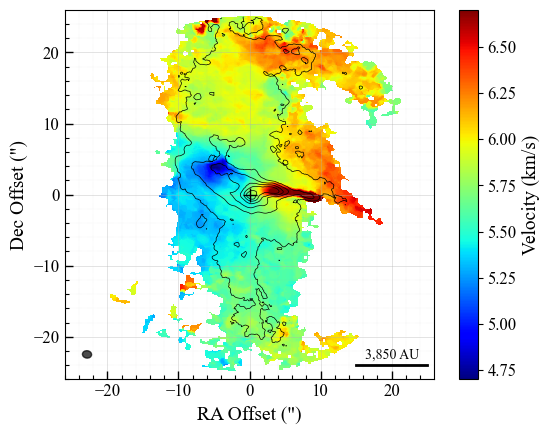

In [37]:
# Plot using offsets
fig, ax = plt.subplots()
# im = ax.imshow(data_moment1_H2CO, origin='lower', cmap='jet', vmin=vmin_H2CO, vmax=vmax_H2CO, extent=[
#     ra_offsets.min(), ra_offsets.max(),
#     dec_offsets.min(), dec_offsets.max()])

im = ax.imshow(data_moment1_H2CO, origin='lower', cmap='jet', vmin=4.7, vmax=6.7, extent=[
    ra_offsets.min(), ra_offsets.max(),
    dec_offsets.min(), dec_offsets.max()])

# Plot contours
plot_contours(data_moment0_H2CO, 'black', sigma_H2CO, sigma_min=5, sigma_max=60, sigma_step=10)

# Plot the protostar marker
ax.plot(0, 0, marker='+', color='black', markersize=10, label='Marker')

# Set labels
ax.set_xlabel('RA Offset (")')
ax.set_ylabel('Dec Offset (")')
# ax.set_title(r'H$_2$CO')

# Move ticks inside
ax.tick_params(axis='both', direction='in', which='both')

# Add colorbar
plt.colorbar(im, ax=ax, label='Velocity (km/s)')

# Add beam
beam_H2CO = beam(1.29, 1.04, 83.63, 16, 15)
ax.add_patch(beam_H2CO)

# Set offset limits
ax.set_xlim(-25, 26)
ax.set_ylim(-25, 26)

# Set major ticks      
ax.set_xticks(np.arange(-20, 25, 10))
ax.set_yticks(np.arange(-20, 25, 10))

# Set minor ticks  
ax.set_xticks(np.arange(-26, 26, 2), minor=True)
ax.set_yticks(np.arange(-26, 26, 2), minor=True)

# Change tick appearance
ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

# Set starting point for the scale bar (in arcseconds)
x_start = ax.get_xlim()[0] + 41      
y_start = ax.get_ylim()[0] + 2         

# Length of the bar in arcseconds
scale_bar_length = 10      

# Plot the scale bar
ax.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

# Label it
ax.text(x_start + scale_bar_length / 2, y_start + 0.5, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.5)
ax.grid(which='minor', linestyle=':', linewidth=0.3, alpha=0.3)

# Save image
plt.savefig("HOPS164_H2CO_moment1_map.png", format="png", dpi=300, bbox_inches="tight")
plt.savefig("HOPS164_H2CO_moment1_map.pdf", format="pdf", dpi=300, bbox_inches="tight")

# Close imshow
plt.show()

# N2Dp Moment 0

In [4]:
# cube_N2Dp=SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/N2Dp/HOPS164_N2Dp_Tp12m7m_large_Combine_pbcor.fits')
# cube_N2Dp = cube_N2Dp.to(u.K).with_spectral_unit(u.km/u.s)

cube_N2Dp=SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/N2Dp/HOPS164_N2Dp_large_sm_reb.fits')
cube_N2Dp = cube_N2Dp.to(u.K).with_spectral_unit(u.km/u.s)

In [ ]:
# Access robust data
data_robust = cube_N2Dp.hdu.data

# Convert pixel grid to world coordinates
nx = cube_N2Dp.shape[1]
ny = cube_N2Dp.shape[2]
y_pix, x_pix = np.mgrid[:ny, :nx]
sky = pixel_to_skycoord(x_pix, y_pix, cube_N2Dp.wcs.celestial)

# Convert sky coordinates to offset frame
offset_coords = sky.transform_to(offset_frame)
ra_offsets = -offset_coords.lon.arcsec
dec_offsets = offset_coords.lat.arcsec

In [6]:
vmin_N2Dp = 3.9
vmax_N2Dp = 7.5

# sigma_N2Dp = 0.008
sigma_N2Dp = 0.16 # sm_reb

mask = cube_N2Dp > 3 * sigma_N2Dp * u.K # 0.11 being snr
mask_array = mask.include()
planemask = remove_small_objects(mask_array, min_size=50)
# cube_N2Dp = cube_N2Dp.with_mask(planemask)


In [7]:
slab_N2Dp = cube_N2Dp.spectral_slab(vmin_N2Dp*u.km/u.s, vmax_N2Dp*u.km/u.s)
data_moment0_N2Dp = slab_N2Dp.moment(order=0).hdu.data

slab_N2Dp = cube_N2Dp.spectral_slab(vmin_N2Dp*u.km/u.s, vmax_N2Dp*u.km/u.s)
data_moment1_N2Dp = slab_N2Dp.moment(order=0).hdu.data

In [8]:
# Finding RMS
dv = np.abs(np.diff(slab_N2Dp.spectral_axis)[0])
N = slab_N2Dp.shape[0]
sigma_N2Dp = sigma_N2Dp * np.sqrt(N) * dv
print(sigma_N2Dp)

0.08584469221033235 km / s


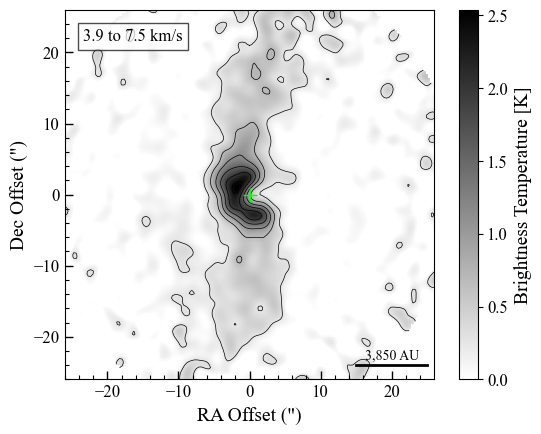

In [10]:
# Plot using offsets
fig, ax = plt.subplots()
im = ax.imshow(data_moment0_N2Dp, origin='lower', cmap='binary', vmin=0, extent=[
    ra_offsets.min(), ra_offsets.max(),
    dec_offsets.min(), dec_offsets.max()])

# Plot contours
plot_contours(data_moment0_N2Dp, 'black', sigma_N2Dp, sigma_min=3, sigma_max=40, sigma_step=5)

# Plot the protostar marker
ax.plot(0, 0, marker='+', color='lime', markersize=10, label='Marker')

# Add labels
ax.set_xlabel('RA Offset (")')
ax.set_ylabel('Dec Offset (")')
# ax.set_title(r'N$_2$D$^+$')

# Add velocity label in the top left of the subplot
ax.text(0.05, 0.95, f"{vmin_N2Dp:.1f} to {vmax_N2Dp:.1f} km/s", transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))

# Move ticks inside
ax.tick_params(axis='both', direction='in', which='both')

# Add colorbar
plt.colorbar(im, ax=ax, label='Brightness Temperature [K]')

# Add it to the plot
beam_N2Dp = beam(1.22, 0.98, 84.98, 10, 10)
ax.add_patch(beam_N2Dp)

# Set offset limits
ax.set_xlim(-25, 26)
ax.set_ylim(-25, 26)

# Set major ticks      
ax.set_xticks(np.arange(-20, 25, 10))
ax.set_yticks(np.arange(-20, 25, 10))

# Set minor ticks  
ax.set_xticks(np.arange(-26, 26, 2), minor=True)
ax.set_yticks(np.arange(-26, 26, 2), minor=True)

# Change tick appearance
ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

# Set starting point for the scale bar (in arcseconds)
x_start = ax.get_xlim()[0] + 41      
y_start = ax.get_ylim()[0] + 2   

# Length of the bar in arcseconds
scale_bar_length = 10      

# Plot the scale bar
ax.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

# Label it
ax.text(x_start + scale_bar_length / 2, y_start + 0.5, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

# Save image
plt.savefig("HOPS164_N2Dp_contour_map.png", format="png", dpi=300, bbox_inches="tight")
plt.savefig("HOPS164_N2Dp_contour_map.pdf", format="pdf", dpi=300, bbox_inches="tight")

# Close imshow
plt.show()

# N2Dp Moment 1

In [107]:
hdul = fits.open('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/N2Dp/NAN_HOPS164fit_thin_snr3.fits')
data = hdul[0].data
header = hdul[0].header

print(data.shape)

(8, 224, 224)


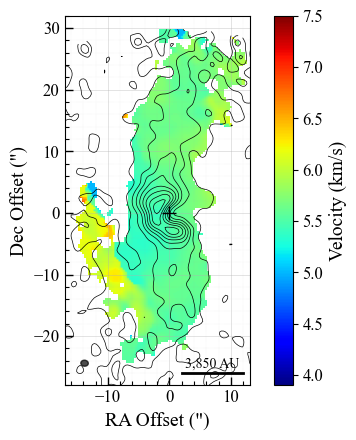

In [108]:
# Plot using offsets
fig, ax = plt.subplots()

im = ax.imshow(data[2], origin='lower', cmap='jet', vmin=3.9, vmax=7.5, extent=[
    ra_offsets.min(), ra_offsets.max(),
    dec_offsets.min(), dec_offsets.max()])

# Plot contours
plot_contours(data_moment0_N2Dp, 'black', sigma_N2Dp, sigma_min=3, sigma_max=80, sigma_step=10)

# Plot the protostar marker
ax.plot(0, 0, marker='+', color='black', markersize=10, label='Marker')

# Add labels
ax.set_xlabel('RA Offset (")')
ax.set_ylabel('Dec Offset (")')
# ax.set_title(r'N$_2$D$^+$')

# Move ticks inside
ax.tick_params(axis='both', direction='in', which='both')

# Add colorbar
plt.colorbar(im, ax=ax, label='Velocity (km/s)')

# Add it to the plot
beam_N2Dp = beam(1.22, 0.98, 84.98, 25, 13)
ax.add_patch(beam_N2Dp)

# Set major ticks 
ax.set_xticks(np.arange(-20, 11, 10))
ax.set_yticks(np.arange(-30, 31, 10))

# Set minor ticks 
ax.set_xticks(np.arange(-20, 14, 2), minor=True)
ax.set_yticks(np.arange(-30, 34, 2), minor=True)

# Change tick appearance
ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

# Set offset limits
ax.set_xlim(-17, 13) 
ax.set_ylim(-28, 32)

# Set starting point for the scale bar (in arcseconds)
x_start = ax.get_xlim()[0] + 19    
y_start = ax.get_ylim()[0] + 2    

# Length of the bar in arcseconds
scale_bar_length = 10  

# Plot the scale bar
ax.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

# Label it
ax.text(x_start + scale_bar_length / 2, y_start + 0.5, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.5)
ax.grid(which='minor', linestyle=':', linewidth=0.3, alpha=0.3)

# Save image
# plt.savefig("HOPS164_N2Dp_moment1_map.png", format="png", dpi=300, bbox_inches="tight")
# plt.savefig("HOPS164_N2Dp_moment1_map.pdf", format="pdf", dpi=300, bbox_inches="tight")

# Close imshow
plt.show()

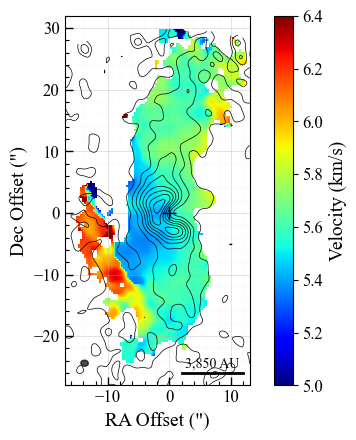

In [109]:
# Plot using offsets
fig, ax = plt.subplots()

# im = ax.imshow(data_moment1_N2Dp, origin='lower', cmap='jet', vmin=3.9, vmax=7.5, extent=[
#     ra_offsets.min(), ra_offsets.max(),
#     dec_offsets.min(), dec_offsets.max()])

im = ax.imshow(data[2], origin='lower', cmap='jet', vmin=5.0, vmax=6.4, extent=[
    ra_offsets.min(), ra_offsets.max(),
    dec_offsets.min(), dec_offsets.max()])

# Plot contours
plot_contours(data_moment0_N2Dp, 'black', sigma_N2Dp, sigma_min=3, sigma_max=80, sigma_step=10)

# Plot the protostar marker
ax.plot(0, 0, marker='+', color='black', markersize=10, label='Marker')

# Add labels
ax.set_xlabel('RA Offset (")')
ax.set_ylabel('Dec Offset (")')
# ax.set_title(r'N$_2$D$^+$')

# Move ticks inside
ax.tick_params(axis='both', direction='in', which='both')

# Add colorbar
plt.colorbar(im, ax=ax, label='Velocity (km/s)')

# Add it to the plot
beam_N2Dp = beam(1.22, 0.98, 84.98, 25, 13)
ax.add_patch(beam_N2Dp)

# Set major ticks 
ax.set_xticks(np.arange(-20, 11, 10))
ax.set_yticks(np.arange(-30, 31, 10))

# Set minor ticks 
ax.set_xticks(np.arange(-20, 14, 2), minor=True)
ax.set_yticks(np.arange(-30, 34, 2), minor=True)

# Change tick appearance
ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

# Set offset limits
ax.set_xlim(-17, 13) 
ax.set_ylim(-28, 32)

# Set starting point for the scale bar (in arcseconds)
x_start = ax.get_xlim()[0] + 19    
y_start = ax.get_ylim()[0] + 2    

# Length of the bar in arcseconds
scale_bar_length = 10  

# Plot the scale bar
ax.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

# Label it
ax.text(x_start + scale_bar_length / 2, y_start + 0.5, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.5)
ax.grid(which='minor', linestyle=':', linewidth=0.3, alpha=0.3)

# Save image
plt.savefig("HOPS164_N2Dp_all_moment1_map.png", format="png", dpi=300, bbox_inches="tight")
plt.savefig("HOPS164_N2Dp_all_moment1_map.pdf", format="pdf", dpi=300, bbox_inches="tight")

# Close imshow
plt.show()

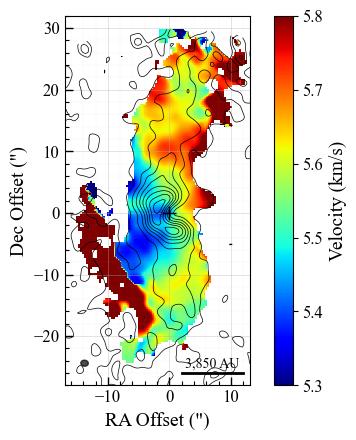

In [110]:
# Plot using offsets
fig, ax = plt.subplots()
# im = ax.imshow(data_moment1_N2Dp, origin='lower', cmap='jet', vmin=5.3, vmax=6.0, extent=[
#     ra_offsets.min(), ra_offsets.max(),
#     dec_offsets.min(), dec_offsets.max()])

im = ax.imshow(data[2], origin='lower', cmap='jet', vmin=5.3, vmax=5.8, extent=[
    ra_offsets.min(), ra_offsets.max(),
    dec_offsets.min(), dec_offsets.max()])

# Plot contours
plot_contours(data_moment0_N2Dp, 'black', sigma_N2Dp, sigma_min=3, sigma_max=80, sigma_step=10)

# Plot the protostar marker
ax.plot(0, 0, marker='+', color='black', markersize=10, label='Marker')

# Add labels
ax.set_xlabel('RA Offset (")')
ax.set_ylabel('Dec Offset (")')
# ax.set_title(r'N$_2$D$^+$')

# Move ticks inside
ax.tick_params(axis='both', direction='in', which='both')

# Add colorbar
plt.colorbar(im, ax=ax, label='Velocity (km/s)')

# Add it to the plot
beam_N2Dp = beam(1.22, 0.98, 84.98, 25, 13)
ax.add_patch(beam_N2Dp)

# Set major ticks 
ax.set_xticks(np.arange(-20, 11, 10))
ax.set_yticks(np.arange(-30, 31, 10))

# Set minor ticks 
ax.set_xticks(np.arange(-20, 14, 2), minor=True)
ax.set_yticks(np.arange(-30, 34, 2), minor=True)

# Change tick appearance
ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

# Set offset limits
ax.set_xlim(-17, 13) 
ax.set_ylim(-28, 32)

# Set starting point for the scale bar (in arcseconds)
x_start = ax.get_xlim()[0] + 19    
y_start = ax.get_ylim()[0] + 2    

# Length of the bar in arcseconds
scale_bar_length = 10  

# Plot the scale bar
ax.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

# Label it
ax.text(x_start + scale_bar_length / 2, y_start + 0.5, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.5)
ax.grid(which='minor', linestyle=':', linewidth=0.3, alpha=0.3)

# Save image
plt.savefig("HOPS164_N2Dp_moment1_map.png", format="png", dpi=300, bbox_inches="tight")
plt.savefig("HOPS164_N2Dp_moment1_map.pdf", format="pdf", dpi=300, bbox_inches="tight")

# Close imshow
plt.show()

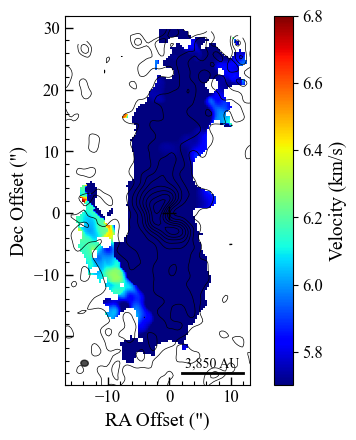

In [111]:
# Plot using offsets
fig, ax = plt.subplots()
# im = ax.imshow(data_moment1_N2Dp, origin='lower', cmap='jet', vmin=3.9, vmax=7.5, extent=[
#     ra_offsets.min(), ra_offsets.max(),
#     dec_offsets.min(), dec_offsets.max()])

im = ax.imshow(data[2], origin='lower', cmap='jet', vmin=5.7, vmax=6.8, extent=[
    ra_offsets.min(), ra_offsets.max(),
    dec_offsets.min(), dec_offsets.max()])

# Plot contours
plot_contours(data_moment0_N2Dp, 'black', sigma_N2Dp, sigma_min=3, sigma_max=80, sigma_step=10)

# Plot the protostar marker
ax.plot(0, 0, marker='+', color='black', markersize=10, label='Marker')

# Add labels
ax.set_xlabel('RA Offset (")')
ax.set_ylabel('Dec Offset (")')
# ax.set_title(r'N$_2$D$^+$')

# Move ticks inside
ax.tick_params(axis='both', direction='in', which='both')

# Add colorbar
plt.colorbar(im, ax=ax, label='Velocity (km/s)')

# Add it to the plot
beam_N2Dp = beam(1.22, 0.98, 84.98, 25, 13)
ax.add_patch(beam_N2Dp)

# Set major ticks 
ax.set_xticks(np.arange(-20, 11, 10))
ax.set_yticks(np.arange(-30, 31, 10))

# Set minor ticks 
ax.set_xticks(np.arange(-20, 14, 2), minor=True)
ax.set_yticks(np.arange(-30, 34, 2), minor=True)

# Change tick appearance
ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

# Set offset limits
ax.set_xlim(-17, 13) 
ax.set_ylim(-28, 32)

# Set starting point for the scale bar (in arcseconds)
x_start = ax.get_xlim()[0] + 19    
y_start = ax.get_ylim()[0] + 2    

# Length of the bar in arcseconds
scale_bar_length = 10  

# Plot the scale bar
ax.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

# Label it
ax.text(x_start + scale_bar_length / 2, y_start + 0.5, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

# Save image
plt.savefig("HOPS164_N2Dp_tail_moment1_map.png", format="png", dpi=300, bbox_inches="tight")
plt.savefig("HOPS164_N2Dp_tail_moment1_map.pdf", format="pdf", dpi=300, bbox_inches="tight")

# Close imshow
plt.show()

# Circumstellar Environment Map

In [126]:
hdul = fits.open("/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/N2Dp/HOPS164_N2Dp_large_sm_reb.fits.moment.integrated")
wcs = WCS(hdul[0].header)
N2Dp_lowres_data = hdul[0].data

pixel_scales = proj_plane_pixel_scales(wcs)  # degrees/pixel
scale = pixel_scales[0] * 3600  # convert to arcsec/pixel

print("Pixel scale (arcmin/pixel):", scale)

Pixel scale (arcmin/pixel): 0.339999999999984


In [127]:
z, nx, ny = N2Dp_lowres_data.shape
scale = 0.34   # arcmin/pixel
print(nx, ny)

extent_N2Dp_lowres = [
    -nx/2 * scale,   # xmin
     nx/2 * scale,   # xmax
    -ny/2 * scale,   # ymin
     ny/2 * scale    # ymax
]

224 224


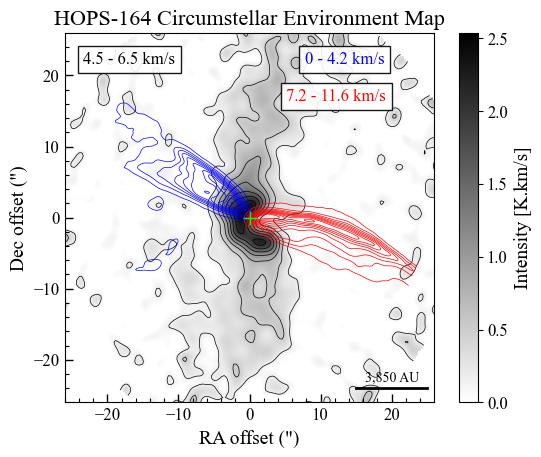

In [128]:
# Plot using offsets
fig, ax = plt.subplots()
im = ax.imshow(data_moment0_N2Dp, origin='lower', cmap='binary', vmin=0, extent=extent_N2Dp_lowres)

# Plot contours
plot_contours2(data_moment0_N2Dp.data, 'black', sigma_N2Dp, sigma_min=5, sigma_max=150, sigma_step=10, ax=ax, extent=extent_N2Dp_lowres)
plot_contours(data_moment0_12CO_blue.data, 'blue', sigma_12CO, sigma_min=30, sigma_max=400, sigma_step=40)
plot_contours(data_moment0_12CO_red.data, 'red', sigma_12CO, sigma_min=100, sigma_max=450, sigma_step=40)

# Plot the protostar marker
ax.plot(0, 0, marker='+', color='lime', markersize=10, label='Marker')

# Set labels
ax.set_xlabel('RA offset (")')
ax.set_ylabel('Dec offset (")')
ax.set_title('HOPS-164 Circumstellar Environment Map')

# Add velocity label in the top left of the subplot
ax.text(0.05, 0.95, f"{4.5:.1f} - {6.5:.1f} km/s", transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.9))
ax.text(0.65, 0.95, f"{0:.0f} - {4.2:.1f} km/s", transform=ax.transAxes, fontsize=12, verticalalignment='top', color = 'blue', bbox=dict(facecolor='white', alpha=0.9))
ax.text(0.60, 0.85, f"{7.2:.1f} - {11.6:.1f} km/s", transform=ax.transAxes, fontsize=12, verticalalignment='top', color = 'red', bbox=dict(facecolor='white', alpha=0.9))

# Set offset limits
ax.set_xlim(-25, 26)
ax.set_ylim(-25, 26)

# Set major ticks      
ax.set_xticks(np.arange(-20, 25, 10))
ax.set_yticks(np.arange(-20, 25, 10))

# Set minor ticks  
ax.set_xticks(np.arange(-26, 26, 2), minor=True)
ax.set_yticks(np.arange(-26, 26, 2), minor=True)

# Change tick appearance
ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

# Set starting point for the scale bar (in arcseconds)
x_start = ax.get_xlim()[0] + 41      
y_start = ax.get_ylim()[0] + 2       

# Length of the bar in arcseconds
scale_bar_length = 10    

# Add colorbar
plt.colorbar(im, ax=ax, label='Intensity [K.km/s]')

# Plot the scale bar
ax.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

# Label it
ax.text(x_start + scale_bar_length / 2, y_start + 0.5, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

# Save image
plt.savefig("HOPS164_circumstellar_environment_map.png", format="png", dpi=300, bbox_inches="tight")

# Close imshow
plt.show()

# ALL MOMENT 1

In [39]:
# Helper function
def add_panel_label(ax, label, x=0.02, y=0.97):
    ax.text(x, y, f'({label})', transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')

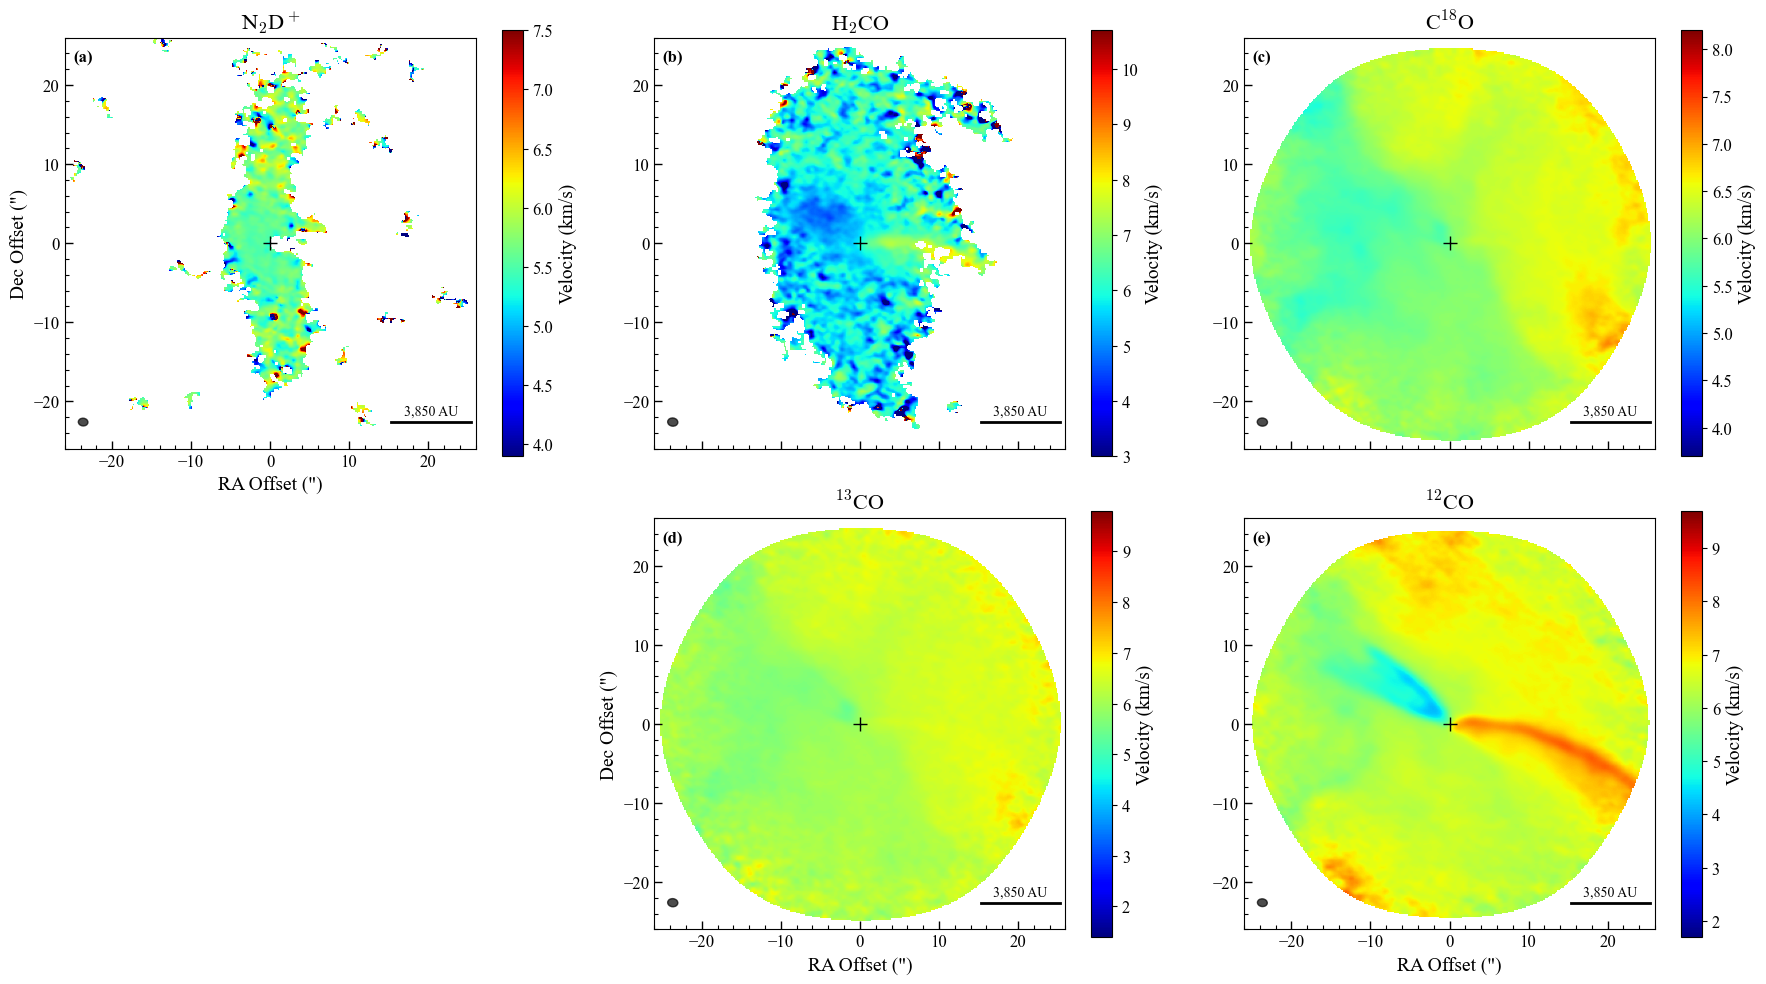

In [ ]:
fig = plt.figure(figsize=(18, 10))

ax0 = fig.add_subplot(2, 3, 1)
ax1 = fig.add_subplot(2, 3, 2)
ax2 = fig.add_subplot(2, 3, 3)
ax3 = fig.add_subplot(2, 3, 5)
ax4 = fig.add_subplot(2, 3, 6)

add_panel_label(ax0, 'a')
add_panel_label(ax1, 'b')
add_panel_label(ax2, 'c')
add_panel_label(ax3, 'd')
add_panel_label(ax4, 'e')


# Plot using offsets
im0 = ax0.imshow(data_moment1_N2Dp, origin='lower', cmap='jet', vmin=3.9, vmax=7.5, extent=[
    ra_offsets.min(), ra_offsets.max(),
    dec_offsets.min(), dec_offsets.max()])

# Plot contours
plot_contours(data_N2Dp, 'black', sigma_N2Dp, sigma_min=3, sigma_max=25, sigma_step=4)

# Plot the protostar marker
ax0.plot(0, 0, marker='+', color='black', markersize=10, label='Marker')

# Add labels
ax0.set_xlabel('RA Offset (")')
ax0.set_ylabel('Dec Offset (")')
ax0.set_title(r'N$_2$D$^+$')

# Move ticks inside
ax0.tick_params(axis='both', direction='in', which='both')

# Add colorbar
plt.colorbar(im0, ax=ax0, label='Velocity (km/s)')

# Add it to the plot
beam_N2Dp = beam(1.22, 0.98, 84.98, 15, 15)
ax0.add_patch(beam_N2Dp)

# Set major ticks      
ax0.set_xticks(np.arange(-20, 30, 10))
ax0.set_yticks(np.arange(-20, 30, 10))

# Set minor ticks  
ax0.set_xticks(np.arange(-28, 30, 2), minor=True)
ax0.set_yticks(np.arange(-28, 30, 2), minor=True)

# Change tick appearance
ax0.tick_params(axis='both', which='major', length=6, width=1, direction='in')
ax0.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

# Set starting point for the scale bar (in arcseconds)
x_start = ax0.get_xlim()[0] + 54      
y_start = ax0.get_ylim()[0] + 15       

# Length of the bar in arcseconds
scale_bar_length = 10      

# Plot the scale bar
ax0.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

# Label it
ax0.text(x_start + scale_bar_length / 2, y_start + 0.5, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

# Set offset limits
ax0.set_xlim(-26, 26) 
ax0.set_ylim(-26, 26)







# Plot using offsets
im1 = ax1.imshow(data_moment1_H2CO, origin='lower', cmap='jet', vmin=vmin_H2CO, vmax=vmax_H2CO, extent=[
    ra_offsets.min(), ra_offsets.max(),
    dec_offsets.min(), dec_offsets.max()
])

# Plot contours
plot_contours(data_H2CO, 'black', sigma_H2CO, sigma_min=5, sigma_max=50, sigma_step=5)

# Plot the protostar marker
ax1.plot(0, 0, marker='+', color='black', markersize=10, label='Marker')

# Set labels
ax1.set_xlabel('RA Offset (")')
ax1.set_ylabel('Dec Offset (")')
ax1.set_title(r'H$_2$CO')

# Move ticks inside
ax1.tick_params(axis='both', direction='in', which='both')

# Add colorbar
plt.colorbar(im1, ax=ax1, label='Velocity (km/s)')

# Add beam
beam_H2CO = beam(1.29, 1.04, 83.63, 15, 15)
ax1.add_patch(beam_H2CO)

# Set major ticks      
ax1.set_xticks(np.arange(-20, 30, 10))
ax1.set_yticks(np.arange(-20, 30, 10))

# Set minor ticks  
ax1.set_xticks(np.arange(-28, 30, 2), minor=True)
ax1.set_yticks(np.arange(-28, 30, 2), minor=True)

# Change tick appearance
ax1.tick_params(axis='both', which='major', length=6, width=1, direction='in')
ax1.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

# Set starting point for the scale bar (in arcseconds)
x_start = ax1.get_xlim()[0] + 54      
y_start = ax1.get_ylim()[0] + 15       

# Length of the bar in arcseconds
scale_bar_length = 10      

# Plot the scale bar
ax1.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

# Label it
ax1.text(x_start + scale_bar_length / 2, y_start + 0.5, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

# Set offset limits
ax1.set_xlim(-26, 26) 
ax1.set_ylim(-26, 26)






# Plot using offsets
im2 = ax2.imshow(data_moment1_C18O, origin='lower', cmap='jet', vmin=vmin_C18O, vmax= vmax_C18O, extent=[
    ra_offsets.min(), ra_offsets.max(),
    dec_offsets.min(), dec_offsets.max()
])

# Plot contours
plot_contours(data_C18O, 'black', sigma_C18O, sigma_min=5, sigma_max=250, sigma_step=20)

# Plot the protostar marker
ax2.plot(0, 0, marker='+', color='black', markersize=10, label='Marker')

# Set labels
ax2.set_xlabel('RA Offset (")')
ax2.set_ylabel('Dec Offset (")')
ax2.set_title(r'C$^{18}$O')

# Move ticks inside
ax2.tick_params(axis='both', direction='in', which='both')

# Add colorbar
plt.colorbar(im2, ax=ax2, label='Velocity (km/s)')

# Add beam
beam_C18O = beam(1.30, 1.03, 85.77, 15, 15)
ax2.add_patch(beam_C18O)

# Set major ticks      
ax2.set_xticks(np.arange(-20, 30, 10))
ax2.set_yticks(np.arange(-20, 30, 10))

# Set minor ticks  
ax2.set_xticks(np.arange(-28, 30, 2), minor=True)
ax2.set_yticks(np.arange(-28, 30, 2), minor=True)

# Change tick appearance
ax2.tick_params(axis='both', which='major', length=6, width=1, direction='in')
ax2.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

# Set starting point for the scale bar (in arcseconds)
x_start = ax2.get_xlim()[0] + 54      
y_start = ax2.get_ylim()[0] + 15       

# Length of the bar in arcseconds
scale_bar_length = 10      

# Plot the scale bar
ax2.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

# Label it
ax2.text(x_start + scale_bar_length / 2, y_start + 0.5, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

# Set offset limits
ax2.set_xlim(-26, 26) 
ax2.set_ylim(-26, 26)








im3 = ax3.imshow(data_moment1_13CO, origin='lower', cmap='jet', vmin=vmin_13CO, vmax=vmax_13CO, extent=[
    ra_offsets.min(), ra_offsets.max(),
    dec_offsets.min(), dec_offsets.max()
])

# Plot contours
plot_contours(data_13CO, 'black', sigma_13CO, sigma_min=50, sigma_max=250, sigma_step=10)

# Plot the protostar marker
ax3.plot(0, 0, marker='+', color='black', markersize=10, label='Marker')

# Set labels
ax3.set_xlabel('RA Offset (")')
ax3.set_ylabel('Dec Offset (")')
ax3.set_title(r'$^{13}$CO')

# Move ticks inside
ax3.tick_params(axis='both', direction='in', which='both')

# Add colorbar
plt.colorbar(im3, ax=ax3, label='Velocity (km/s)')

# Add beam
beam_13CO = beam(1.29, 1.03, 84.42, 15, 15)
ax3.add_patch(beam_13CO)

# Set major ticks      
ax3.set_xticks(np.arange(-20, 30, 10))
ax3.set_yticks(np.arange(-20, 30, 10))

# Set minor ticks  
ax3.set_xticks(np.arange(-28, 30, 2), minor=True)
ax3.set_yticks(np.arange(-28, 30, 2), minor=True)

# Change tick appearance
ax3.tick_params(axis='both', which='major', length=6, width=1, direction='in')
ax3.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

# Set starting point for the scale bar (in arcseconds)
x_start = ax3.get_xlim()[0] + 54      
y_start = ax3.get_ylim()[0] + 15       

# Length of the bar in arcseconds
scale_bar_length = 10      

# Plot the scale bar
ax3.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

# Label it
ax3.text(x_start + scale_bar_length / 2, y_start + 0.5, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

# Set offset limits
ax3.set_xlim(-26, 26) 
ax3.set_ylim(-26, 26)










im4 = ax4.imshow(data_moment1_12CO, origin='lower', cmap='jet', vmin=5.7 - 4, vmax=5.7 + 4, extent=[
    ra_offsets.min(), ra_offsets.max(),
    dec_offsets.min(), dec_offsets.max()
])

# Plot contours
plot_contours(data_12CO, 'black', sigma_12CO, sigma_min=50, sigma_max=800, sigma_step=40)

# Plot the protostar marker
ax4.plot(0, 0, marker='+', color='black', markersize=10, label='Marker')

# Set labels
ax4.set_xlabel('RA Offset (")')
ax4.set_ylabel('Dec Offset (")')
ax4.set_title(r'$^{12}$CO')

# Move ticks inside
ax4.tick_params(axis='both', direction='in', which='both')

# Add colorbar
plt.colorbar(im4, ax=ax4, label='Velocity (km/s)')

# Add beam
beam_12CO = beam(1.25, 0.98, 84.20, 15, 15)
ax4.add_patch(beam_12CO)

# Set major ticks      
ax4.set_xticks(np.arange(-20, 30, 10))
ax4.set_yticks(np.arange(-20, 30, 10))

# Set minor ticks  
ax4.set_xticks(np.arange(-28, 30, 2), minor=True)
ax4.set_yticks(np.arange(-28, 30, 2), minor=True)

# Change tick appearance
ax4.tick_params(axis='both', which='major', length=6, width=1, direction='in')
ax4.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

# Set starting point for the scale bar (in arcseconds)
x_start = ax4.get_xlim()[0] + 54      
y_start = ax4.get_ylim()[0] + 15       

# Length of the bar in arcseconds
scale_bar_length = 10      

# Plot the scale bar
ax4.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

# Label it
ax4.text(x_start + scale_bar_length / 2, y_start + 0.5, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

# Set offset limits
ax4.set_xlim(-26, 26)
ax4.set_ylim(-26, 26)





# Hide RA (x-axis) labels for all except bottom row (ax3, ax4, ax5)
for ax in [ax1, ax2]:
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelbottom=False)

# Hide Dec (y-axis) labels for all except left column (ax0, ax3)
for ax in [ax1, ax2, ax4]:
    ax.set_ylabel('')
    ax.tick_params(axis='y', labelbottom=False)

plt.tight_layout()

# Save image
plt.savefig("HOPS164_all_moment1_maps.png", format="png", dpi=300, bbox_inches="tight")
plt.savefig("HOPS164_all_moment1_maps.pdf", format="pdf", dpi=300, bbox_inches="tight")

# Close imshow
plt.show()
